# 95-891 Homework 3 – Computer Vision
Due October 21, 2025

In this homework, we will implement [AlexNet](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks)-like deep, convolutional neural network (CNN) with PyTorch. We are going to use the CNN to classify flowers into the 102 categories.

The homework consists of the following parts:

- Load and prepare data.
- Load a pretrained Alexnet in PyTorch.
- Set up transfer learning for flower classification problem
- Train the model
- Model performance monitoring and analysis with learning curve
- Questions regarding the design choices

## The places requiring an input are marked with "???".

#### 1.1. Load the dataset which are in three folders, namely train, validation, and test

In [2]:
import matplotlib.pyplot as plt
from collections import OrderedDict

from copy import deepcopy
import copy
import torch
from torch import nn
from torch import optim
from torchvision import datasets, transforms, models

# download the data and unzip it. You should have three sets of data
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
data_dir = '/content/drive/MyDrive/AI_Vision/flowers'
train_dir = data_dir + '/train'
valid_dir = data_dir + '/valid'
test_dir = data_dir + '/test'


Mounted at /content/drive


#### 1.2. Preview some images
Use PIL library to preview images

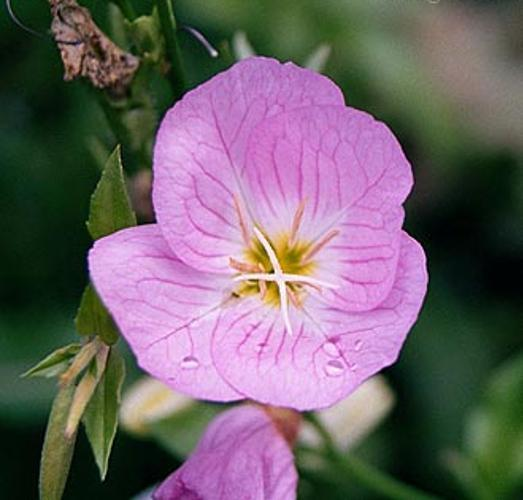

In [3]:
from PIL import Image  #show one example of image

Image.open("/content/drive/MyDrive/AI_Vision/flowers/train/1/image_06734.jpg")

#### 1.3. Data transformation and processing

In [4]:
# Process with some data transformation, do not change
data_transforms = {
    'training': transforms.Compose([transforms.RandomResizedCrop(224),
                                    transforms.RandomHorizontalFlip(),
                                    transforms.RandomRotation(30),
                                    transforms.ToTensor(),
                                    transforms.Normalize([0.485, 0.456, 0.406],
                                                         [0.229, 0.224,
                                                          0.225])]),

    'validation': transforms.Compose([transforms.Resize(256),
                                      transforms.CenterCrop(224),
                                      transforms.ToTensor(),
                                      transforms.Normalize(
                                          [0.485, 0.456, 0.406],
                                          [0.229, 0.224, 0.225])]),

    'testing': transforms.Compose([transforms.Resize(256),
                                   transforms.CenterCrop(224),
                                   transforms.ToTensor(),
                                   transforms.Normalize([0.485, 0.456, 0.406],
                                                        [0.229, 0.224,
                                                         0.225])])
}
# This specifies how many images to process per training/validation
batch_size = 256

image_datasets = {
    'training': datasets.ImageFolder(train_dir,
                                     transform=data_transforms['training']),
    'testing': datasets.ImageFolder(test_dir,
                                    transform=data_transforms['testing']),
    'validation': datasets.ImageFolder(valid_dir,
                                       transform=data_transforms['validation'])
}

dataloaders = {
    'training': torch.utils.data.DataLoader(image_datasets['training'],
                                            batch_size=batch_size,
                                            shuffle=True),
    'testing': torch.utils.data.DataLoader(image_datasets['testing'],
                                           batch_size=batch_size,
                                           shuffle=False),
    'validation': torch.utils.data.DataLoader(image_datasets['validation'],
                                              batch_size=batch_size,
                                              shuffle=True)
}

# get the length of each dataloaders; wit batch size=256, you should have 26 batches of training samples, each with 256 images
training_len = len(dataloaders['training'])
test_len = len(dataloaders['testing'])
validation_len = len(dataloaders['validation'])
class_to_idx = image_datasets['training'].class_to_idx

print('We have ', training_len, 'batches of training images;', 'each with',
      batch_size, 'images')
print('We have ', validation_len, 'batches of validation images;', 'each with',
      batch_size, 'images')

# Let us preview size of each batch
print('Single batch', next(iter(dataloaders['training']))[0].shape)

We have  26 batches of training images; each with 256 images
We have  4 batches of validation images; each with 256 images
Single batch torch.Size([256, 3, 224, 224])


### *Question 1: What is the effect of random flip and rotation in image data transformation?*
- How does it impact the training?
- Why do not we apply them randomly at the validation or test time?

### ANSWER 1:
Random flipping and rotation of images in the training data are augmentation techniques meant to make the model more robust. It does this by showing the model the same item (flower) from different orientations and angles. This forces the model to learn features that are unaffected by orientation. This process reduces overfitting and greatly improves generalization of the model.

### ANSWER 2:
We do not want to apply flip and rotation at the time of validation or testing because those stages are for generating a stable and reproducible measure of the model's performance. Introducing transformations into the test and validation images would affect accuracy, precision, and would not properly represent the model's true capability. Our goal in these stages are to have consistent results without the variety introduced in training.

### *Question 2: Explain the meaning of these numbers for a single batch*
- 256: Batch size - images processed together in one pass.
- 3: RGB, color channels in a pixel.
- 224: Image height in pixels after crop.
- 224: Image width in pixels after crop.

#### 1.4. Initialize the pretrained model

We are going to use an Alexnet convolutional neural network as our pretrained model. The architecture of the network is shown in

 https://bouzouitina-hamdi.medium.com/alexnet-imagenet-classification-with-deep-convolutional-neural-networks-d0210289746b

In [5]:
# Transfer learning with alexnet
model = models.alexnet(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 194MB/s]


### 1.5. Update the classifier of the model to be compatible with our datasets

In [7]:
# In transfer learning, we freeze the feature parameters from the original model
# The most straightforward way is to freeze their gradient update
# see https://pytorch.org/docs/stable/generated/torch.Tensor.requires_grad.html for how to set it
for param in model.parameters():
    param.requires_grad = False

print(model)

# This is the original classifier with alexnet
print()
print('Original classifier of Alexnet')
print(model.classifier)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [8]:
# now we need to replace the classifier by our datasets
# Note, fc2's out_feature should match our number of classes, which is 102

# Tip: check the original AlexNet classifier for some thoughts; they are similar.

# Defining number of hidden units in our fully connected layer
hidden_units = 4096
number_of_flowers = len(class_to_idx)

# Defining the fully connected layer that will be trained on the flower images
classifier = nn.Sequential(OrderedDict([
    ('fc1', nn.Linear(9216, hidden_units)), # Alexnet flattens to 9216 features
    ('relu', nn.ReLU()),
    ('dropout', nn.Dropout(0.5)),
    ('fc2', nn.Linear(hidden_units, number_of_flowers)), # what should be the output of this layer?
    ('output', nn.LogSoftmax(dim=1))
]))


In [9]:
# double check if the classifier of the model is updated.
model.classifier = classifier
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (fc1): Linear(in_features=9216, out_features=4096, bias=True)
    (relu): ReLU()
    (dropout): Drop

### 1.6. Set up the configurations and train it!
- epochs = 30
- since it is a multiclassification problem, we use [negative log likelihood loss](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)
- we use the [Adam optimizer](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html)
- learning rate (lr) = 0.001

In each epoch, we go through all the training samples to update the model, and evaluate with the validation samples to see how good the current model is.
- accuracy: mean of the matches in predicted class and the labels
- loss: negative log likelihood loss


**Sample outputs are provided below; but yours may vary**
**Your validation accuracy may be better than train; this is fine**

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 30
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
criterion = nn.NLLLoss()
print_every = 5

validation_accuracies, training_accuracies = [], []
validation_losses, training_losses = [], []

best_validation_accuracy = 0
best_model_weights = None

for e in range(epochs):

    training_loss = training_accuracy = 0
    validation_loss = validation_accuracy = 0

    model.train()
    for batch_idx, (images, labels) in enumerate(dataloaders['training']):

        # Moving images & labels to the GPU if there is one
        images, labels = images.to(device), labels.to(device)

        # Pushing batch through network, calculating loss & gradient, and updating weights
        log_ps = model.forward(images)
        loss = criterion(log_ps, labels)
        loss.backward()
        optimizer.step()

        # Calculating metrics
        ps = torch.exp(log_ps)
        top_ps, top_class = ps.topk(1, dim=1)
        matches = (top_class == labels.view(*top_class.shape)).type(
            torch.FloatTensor)
        train_batch_accuracy = matches.mean()

        # Resetting optimizer gradient & tracking metrics
        optimizer.zero_grad()
        training_loss += loss.item()
        train_batch_loss = loss.item()
        training_accuracy += train_batch_accuracy.item()

        if batch_idx % print_every == 0:
            # First analyze the training statistics
            print('epoch', e, 'batch', batch_idx)
            print('training loss per batch', train_batch_loss)
            print('training accuracy per batch', train_batch_accuracy.item())

    # Then do the analysis for the validation only at the end of each training epochs
    model.eval()
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(
                dataloaders['validation']):
            images, labels = images.to(device), labels.to(device)
            log_ps = model(images)
            loss =  criterion(log_ps, labels)               # same loss function as training
            ps = torch.exp(log_ps)                         # convert log-probs = probabilities
            top_ps, top_class = ps.topk(1, dim=1)
            matches = (top_class == labels.view(*top_class.shape)).type(
                torch.FloatTensor)
            validation_batch_accuracy = matches.mean()     # fraction correct in this batch

            # Tracking validation metrics
            validation_loss += loss.item()
            validation_batch_loss = loss.item()
            validation_accuracy += validation_batch_accuracy.item()

    # Save the best model weights so far
    # Tip: see this https://pytorch.org/tutorials/beginner/saving_loading_models.html
    if validation_accuracy >= best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_model_weights = copy.deepcopy(model.state_dict()) # snapshot best weights

    # Summary statistic per epoch
    print('epoch', e, 'summary')
    print('avg training loss per epoch', training_loss / training_len)
    print('avg training accuracy per epoch', training_accuracy / training_len)
    training_losses.append(training_loss / training_len)
    training_accuracies.append(training_accuracy / training_len)

    print('avg validation loss per epoch', validation_loss / validation_len)
    print('avg validation accuracy per epoch',
          validation_accuracy / validation_len)
    validation_losses.append(validation_loss / validation_len)
    validation_accuracies.append(validation_accuracy / validation_len)

    print()

epoch 0 batch 0
training loss per batch 4.825414180755615
training accuracy per batch 0.015625
epoch 0 batch 5
training loss per batch 14.552291870117188
training accuracy per batch 0.07421875
epoch 0 batch 10
training loss per batch 9.143473625183105
training accuracy per batch 0.1015625
epoch 0 batch 15
training loss per batch 4.024120330810547
training accuracy per batch 0.1640625
epoch 0 batch 20
training loss per batch 3.0840260982513428
training accuracy per batch 0.28515625
epoch 0 batch 25
training loss per batch 2.740893602371216
training accuracy per batch 0.3815789520740509
epoch 0 summary
avg training loss per epoch 7.649402306630061
avg training accuracy per epoch 0.16626866161823273
avg validation loss per epoch 1.8692579567432404
avg validation accuracy per epoch 0.5499218702316284

epoch 1 batch 0
training loss per batch 2.565275192260742
training accuracy per batch 0.3671875
epoch 1 batch 5
training loss per batch 2.4339089393615723
training accuracy per batch 0.378906

### *Question 3: Report the best model's validation accuracy*
best_validation_accuracy = 0.906

### 1.7. Draw learning curves

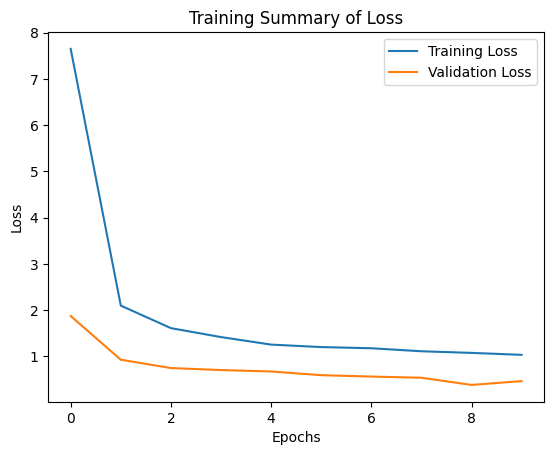

In [13]:
plt.figure()
plt.title("Training Summary of Loss")
plt.plot(training_losses, label='Training Loss')
plt.plot(validation_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

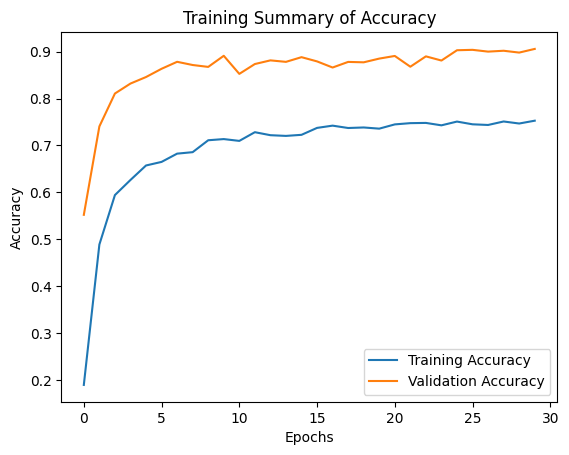

In [13]:
plt.figure()
plt.title("Training Summary of Accuracy")
plt.plot(training_accuracies, label='Training Accuracy')
plt.plot(validation_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### *Question 4: Briefly describe the plots*

### 1.8. Predict on the test data with the best model so far

In [11]:
# Predict on the test data

# Load the best model so far
model.load_state_dict(best_model_weights)
test_accuracy = 0

predictions = []
label_data = []

for images, labels in dataloaders['testing']:
    images, labels = images.to(device), labels.to(device)
    model.eval()
    with torch.no_grad():
        log_ps = model(images)
        ps = torch.exp(log_ps)
        top_ps, top_class = ps.topk(1, dim=1)

    matches = (top_class == labels.view(*top_class.shape)).type(torch.FloatTensor)
    test_accuracy += matches.mean()

    predictions.extend(top_class.cpu().numpy())
    label_data.extend(labels.cpu().numpy())

print('Test Accuracy:', test_accuracy.item() / test_len)

Test Accuracy: 0.8484221696853638


### *Question 5: Report the test accuracy with the best model*
The best test accuracy I saw in my testing was .9058

### *Question 6: Provide a confusion matrix between the ground truth and predicted labels in the test dataset. The rows should correspond to the ground ruth categories and the columns to predicted categories. The confusion matrix here should have raw datapoint counts and should not be normalized as percentages*

### *Question 7: Now normalize the raw confusion matrix reported in the previous question by dividing each row by the sum of all its elements. Include this normalized confusion matrix in your report. It may look small but that is fine. What does the diagnal denote in the normalized confusion matrix? What is the meaning of the number in the row 1 column 2?*

confusion matrix
[[4 0 0 ... 0 0 0]
 [0 3 0 ... 0 0 0]
 [0 0 8 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 0 3 0]
 [0 0 0 ... 0 0 7]]



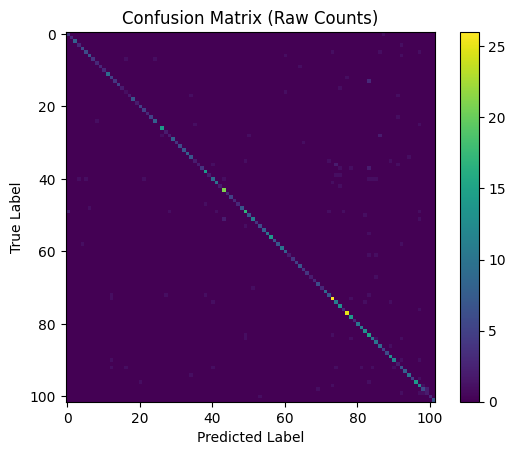

normalized confusion matrix
[[0.8  0.   0.   ... 0.   0.   0.  ]
 [0.   1.   0.   ... 0.   0.   0.  ]
 [0.   0.   1.   ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.4  0.   0.  ]
 [0.   0.   0.   ... 0.   0.75 0.  ]
 [0.   0.   0.   ... 0.   0.   1.  ]]


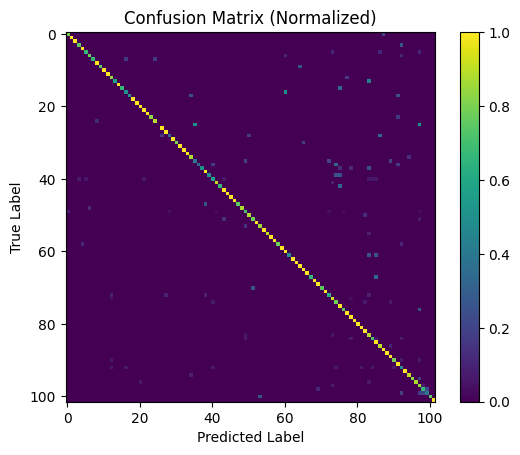

In [15]:
# Please plot the confusion matrix other than print() if possible
from sklearn.metrics import confusion_matrix as conf_mat
import numpy as np
cf =conf_mat(label_data,predictions)

print('confusion matrix')
print(cf)
print()

plt.imshow(cf)
plt.title("Confusion Matrix (Raw Counts)")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# normalized confusion matrix
print('normalized confusion matrix')
ncf = cf / cf.sum(axis=1, keepdims=True)
print(ncf)

plt.imshow(ncf)
plt.title("Confusion Matrix (Normalized)")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### *Question 8: Transfer Learning*
- What is the purpose of a pretrained model and why should it work?

A pretrained model has already been trained on a large dataset across many categories. The purpose is to reuse the learned features rather than training a model from the ground up. Doing it this way would require large data and computational resources. In computer vision a model is taught visual patterns such as edges, shapes, and color that are common across many types of images. Because these patterns are useful in a wide array of cases, they transfer well to new tasks such as flower classification. Using a pretrained model allows the new model achieve higher accuracy with less training. This is especially true when the new dataset is relatively small.

- Why should we freeze the features' gradient in the pretrained model but only update the classifier?

With transfer learning, we freeze the gradients of the feature extraction layers because they contain useful visual features learned during the original “pretraining” process. These layers capture patterns and instead of relearning these representations, we train only the classifier portion of the network so it can map those features to the new dataset. Freezing feature layers reduces the number of trainable parameters, which makes training faster and reduces the risk of overfitting.


- What may happen if we do not freeze the features' gradient?

If feature gradients are not frozen, the training process will update weights in the pretrained network instead of just the classifier. This significantly increases the number of parameters that must be optimized and requires more training data. The model may start to overwrite the useful features learned from the original large dataset. Something called catastrophic forgetting can occur, where the model loses previously learned knowledge while adapting to the new task.